In [10]:
import torch
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("Ultralytics OK")


Torch: 2.9.1+cu128
Ultralytics OK


In [11]:
import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

for clase in os.listdir(dataset_path):
    clase_path = os.path.join(dataset_path, clase)
    if os.path.isdir(clase_path):
        print(clase, ":", len(os.listdir(clase_path)))


train : 4
valid : 4
test : 4


In [12]:
from ultralytics import YOLO

# Cargar un modelo de clasificación preentrenado
# yolo11n-cls.pt para velocidad o yolo11m-cls.pt para precisión

model = YOLO('yolo11m-cls.pt') 

# Entrenar el modelo
results = model.train(
 data='Banana Ripeness Classification.v2-original-images_modifiedclasses.folder', # Ruta a la carpeta raíz del dataset descargado
 epochs=20, # Número de iteraciones
 imgsz=224, # Tamaño de la imagen
 device=0 # Usar GPU (si está disponible)
)

New https://pypi.org/project/ultralytics/8.3.253 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 16083MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Banana Ripeness Classification.v2-original-images_modifiedclasses.folder, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-cls.pt, momentum=0.937, mosaic=1.

In [13]:
# Realizar predicción 
results = model('./ImagenesPrueba/bueno.jpeg')

# Mostrar resultados 
for result in results: 
    print(result.probs)  # Probabilidades de cada clase


image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/bueno.jpeg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 1.6ms
Speed: 1.4ms preprocess, 1.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
ultralytics.engine.results.Probs object with attributes:

data: tensor([2.4915e-06, 9.9954e-01, 4.6062e-04, 1.4297e-07], device='cuda:0')
orig_shape: None
shape: torch.Size([4])
top1: 1
top1conf: tensor(0.9995, device='cuda:0')
top5: [1, 2, 0, 3]
top5conf: tensor([9.9954e-01, 4.6062e-04, 2.4915e-06, 1.4297e-07], device='cuda:0')


In [14]:
# Análisis del Dataset

import os

dataset_path = "Banana Ripeness Classification.v2-original-images_modifiedclasses.folder"

print("=" * 50)
print("ANÁLISIS DEL DATASET")
print("=" * 50)

for split in ['train', 'valid', 'test']:
    split_path = os.path.join(dataset_path, split)
    print(f"\n📁 {split.upper()}:")
    
    total = 0
    for clase in os.listdir(split_path):
        clase_path = os.path.join(split_path, clase)
        if os.path.isdir(clase_path):
            num_images = len(os.listdir(clase_path))
            total += num_images
            print(f"  - {clase}: {num_images} imágenes")
    
    print(f"  TOTAL: {total} imágenes")

print("\n" + "=" * 50)

ANÁLISIS DEL DATASET

📁 TRAIN:
  - overripe: 783 imágenes
  - rotten: 1340 imágenes
  - unripe: 634 imágenes
  - ripe: 1174 imágenes
  TOTAL: 3931 imágenes

📁 VALID:
  - overripe: 229 imágenes
  - rotten: 388 imágenes
  - unripe: 167 imágenes
  - ripe: 339 imágenes
  TOTAL: 1123 imágenes

📁 TEST:
  - overripe: 113 imágenes
  - rotten: 185 imágenes
  - unripe: 110 imágenes
  - ripe: 154 imágenes
  TOTAL: 562 imágenes



📈 RESULTADOS DEL ENTRENAMIENTO


📊 Results.Png


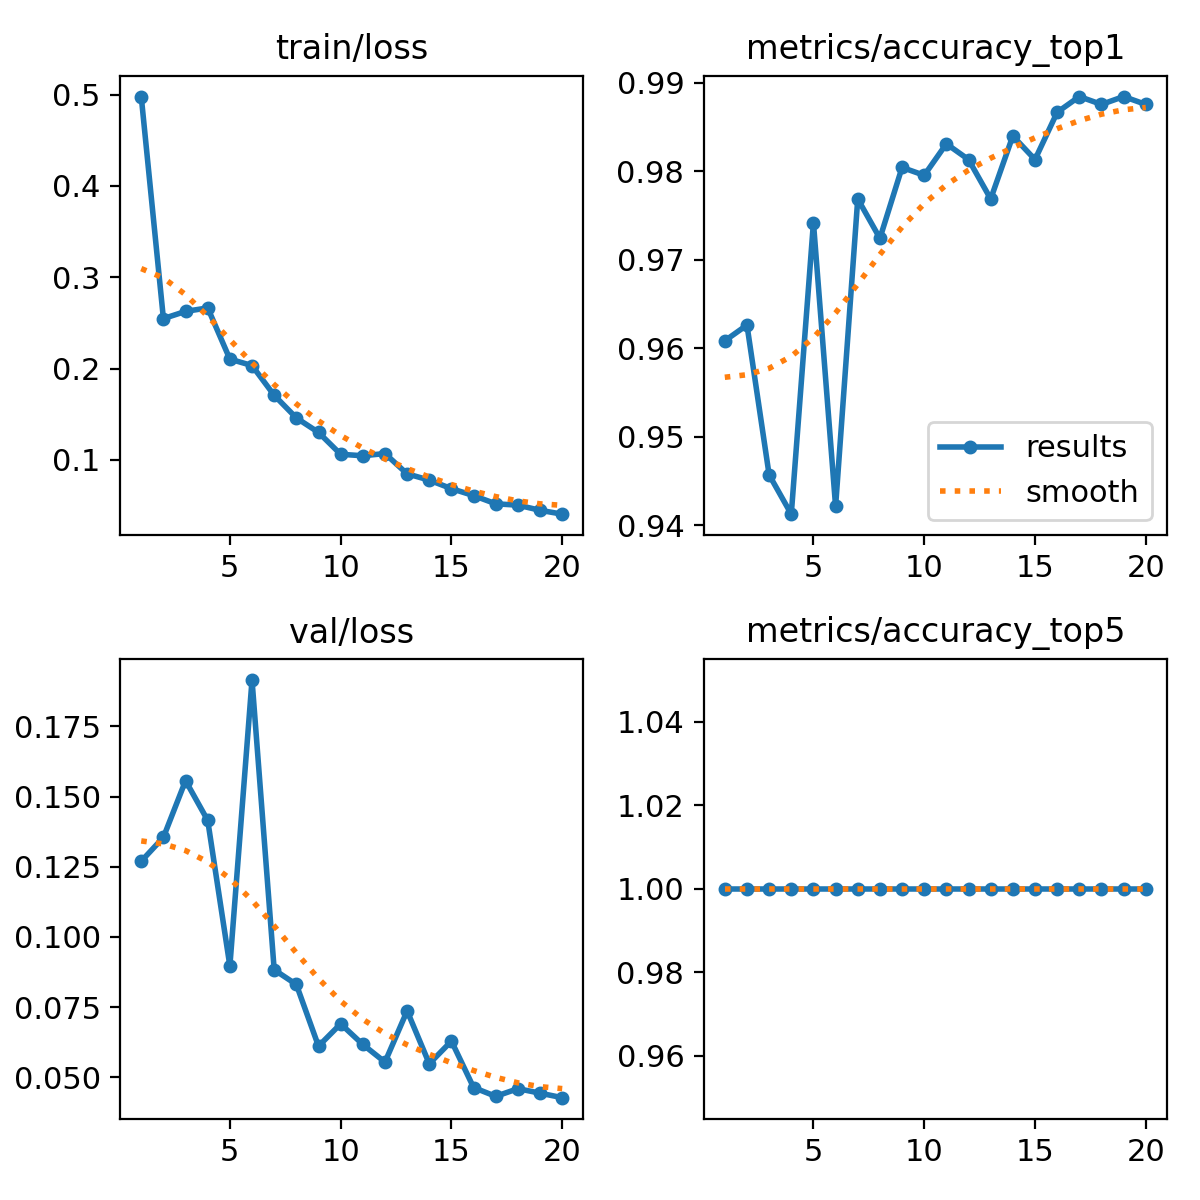


📊 Confusion Matrix.Png


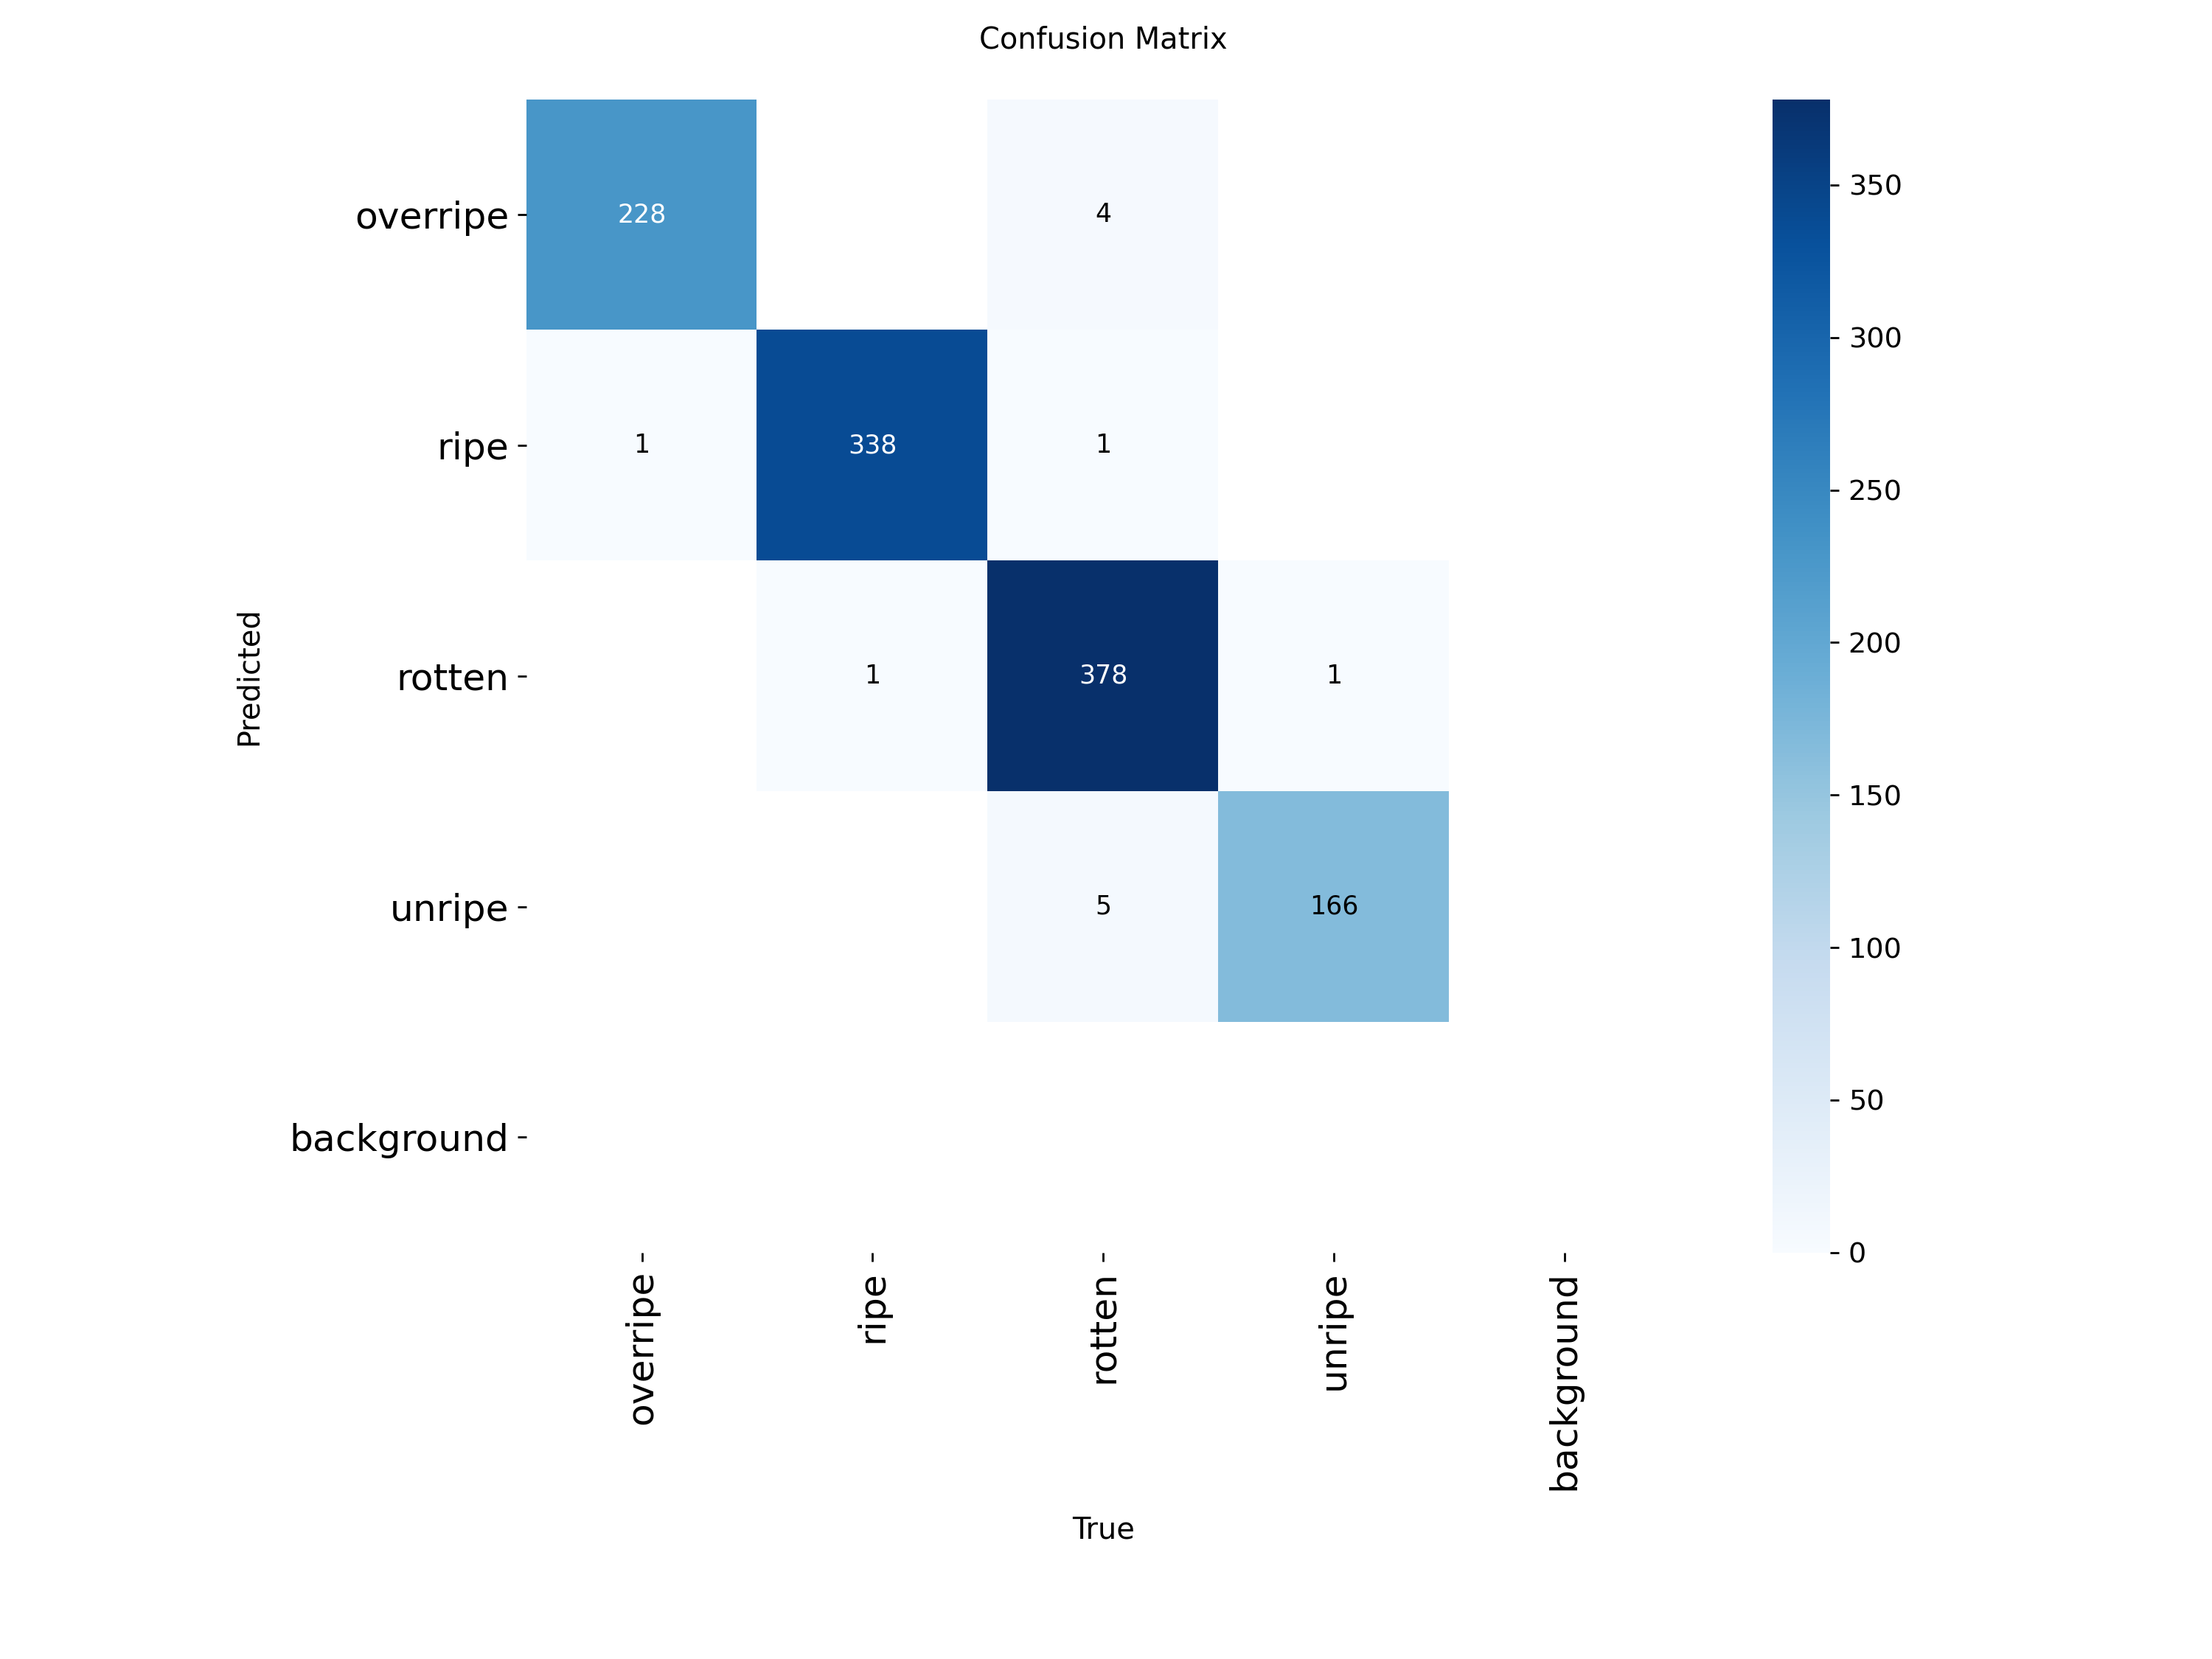


📊 Confusion Matrix Normalized.Png


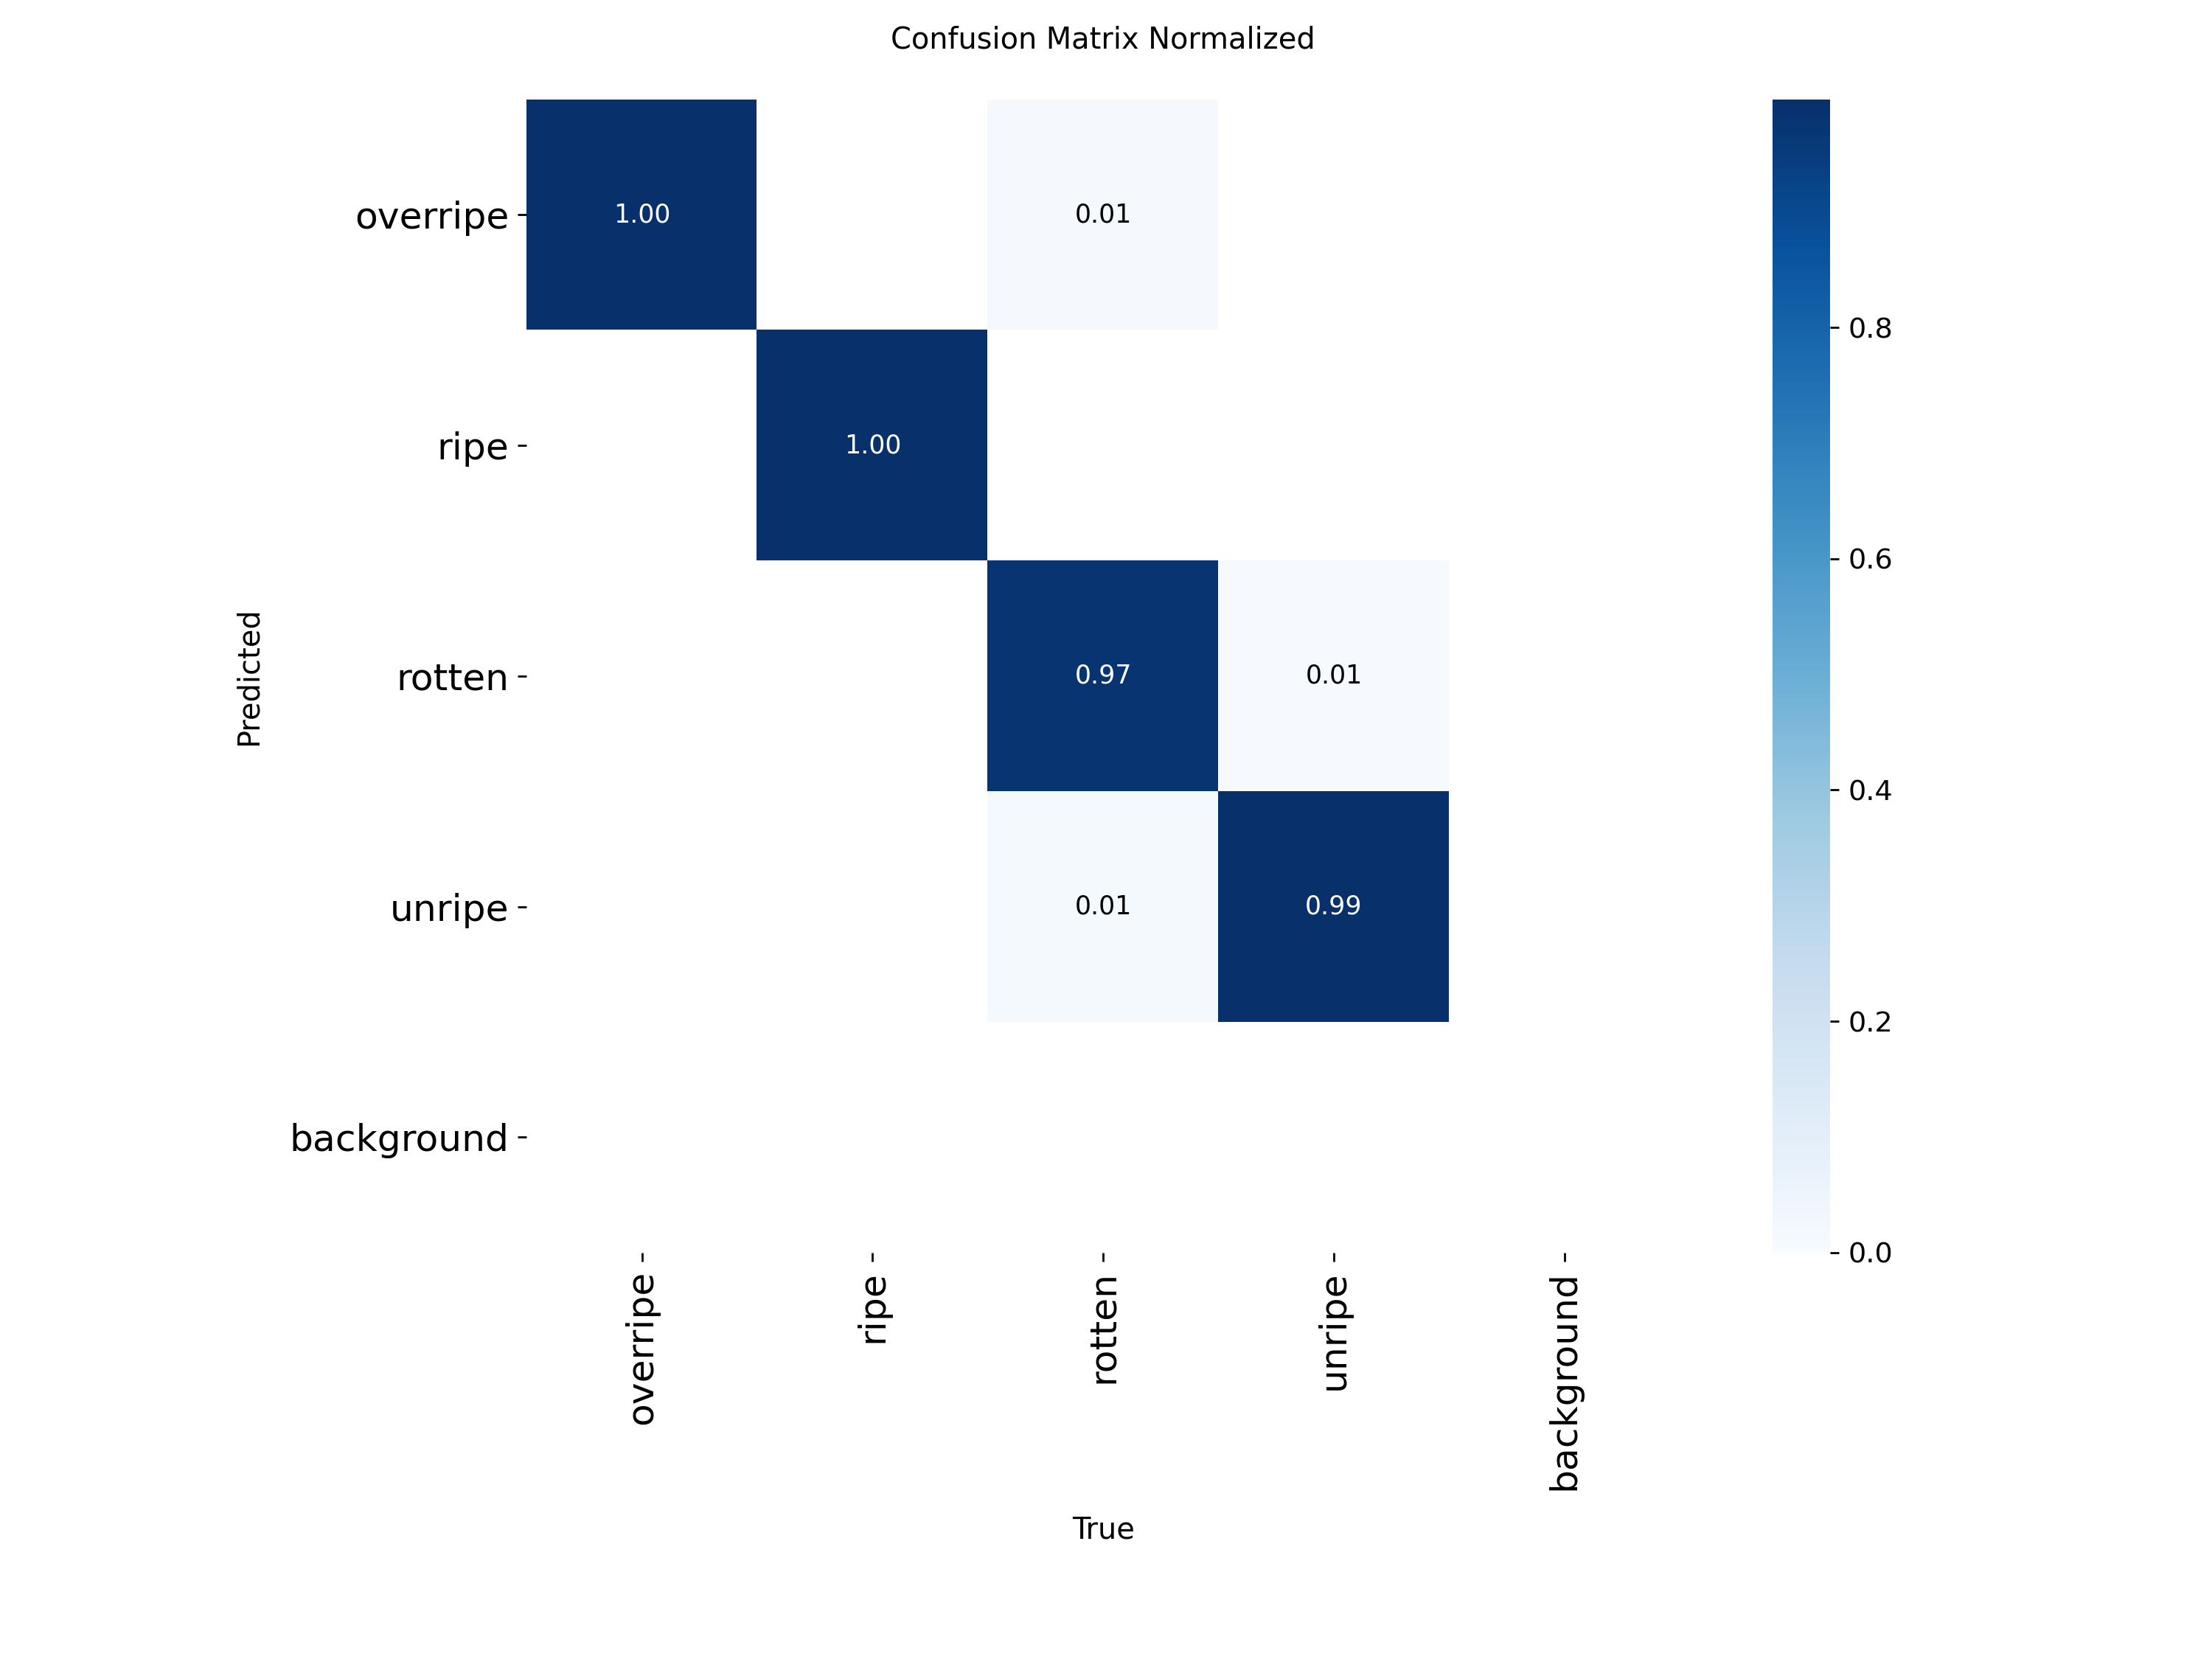

In [15]:
# Visualizar las Métricas de Entrenamiento

from IPython.display import Image, display
import os

print("📈 RESULTADOS DEL ENTRENAMIENTO\n")

# Ruta a los resultados
results_path = "runs/classify/train"

# Mostrar las gráficas generadas
graficas = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']

for grafica in graficas:
    ruta = os.path.join(results_path, grafica)
    if os.path.exists(ruta):
        print(f"\n{'='*50}")
        print(f"📊 {grafica.replace('_', ' ').title()}")
        print('='*50)
        display(Image(filename=ruta))

In [16]:
# Análisis de la Matriz de Confusión

print("""
ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Las clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)

Observaciones:
[Aquí debes escribir tus observaciones, por ejemplo:]
- ¿Qué clases se confunden más entre sí?
- ¿Hay alguna clase que el modelo prediga perfectamente?
- ¿Entre qué clases tiene más dificultad para distinguir?
""")




ANÁLISIS DE LA MATRIZ DE CONFUSIÓN:

Las clases del modelo son:
- overripe (pasado/sobremaduro)
- ripe (maduro)
- rotten (podrido)
- unripe (verde/inmaduro)

Observaciones:
[Aquí debes escribir tus observaciones, por ejemplo:]
- ¿Qué clases se confunden más entre sí?
- ¿Hay alguna clase que el modelo prediga perfectamente?
- ¿Entre qué clases tiene más dificultad para distinguir?



In [ ]:
# Pruebas con Imágenes Reales

import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Lista de imágenes a probar
imagenes_prueba = [
    './ImagenesPrueba/bueno.jpeg',
    './ImagenesPrueba/maduro.jpeg',
    './ImagenesPrueba/normal.jpeg'
]

# Nombres de las clases (en el orden del modelo)
# overripe(sobremaduro/pasado) ripe(maduro) rotten(podrido) unripe(verde)
nombres_clases = ['overripe', 'ripe', 'rotten', 'unripe']

print("🔍 PRUEBAS CON IMÁGENES NUEVAS\n")

for i, img_path in enumerate(imagenes_prueba, 1):
    print(f"\n{'='*60}")
    print(f"IMAGEN {i}: {img_path}")
    print('='*60)
    
    # Realizar predicción
    results = model(img_path)
    
    # Obtener las probabilidades
    probs = results[0].probs.data.cpu().numpy()
    
    # Clase predicha
    clase_predicha = nombres_clases[probs.argmax()]
    confianza = probs.max() * 100
    
    print(f"\n✅ Predicción: {clase_predicha.upper()}")
    print(f"🎯 Confianza: {confianza:.2f}%")
    print(f"\nProbabilidades por clase:")
    for nombre, prob in zip(nombres_clases, probs):
        print(f"  - {nombre}: {prob*100:.2f}%")
    
    # Mostrar la imagen
    plt.figure(figsize=(8, 6))
    img = PILImage.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicción: {clase_predicha} ({confianza:.1f}%)", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Tu evaluación
    print("\n📝 Evaluación:")
    print("¿Es correcta la predicción? [Escribe SI/NO y explica]")
    print("_" * 60)

🔍 PRUEBAS CON IMÁGENES NUEVAS


IMAGEN 1: ./ImagenesPrueba/bueno.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/bueno.jpeg: 224x224 ripe 1.00, rotten 0.00, overripe 0.00, unripe 0.00, 5.3ms
Speed: 18.8ms preprocess, 5.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

✅ Predicción: RIPE
🎯 Confianza: 99.95%

Probabilidades por clase:
  - overripe: 0.00%
  - ripe: 99.95%
  - rotten: 0.05%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>


📝 Evaluación:
¿Es correcta la predicción? [Escribe SI/NO y explica]
____________________________________________________________

IMAGEN 2: ./ImagenesPrueba/maduro.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/maduro.jpeg: 224x224 rotten 0.86, overripe 0.14, ripe 0.00, unripe 0.00, 6.7ms
Speed: 2.1ms preprocess, 6.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

✅ Predicción: ROTTEN
🎯 Confianza: 85.63%

Probabilidades por clase:
  - overripe: 14.37%
  - ripe: 0.00%
  - rotten: 85.63%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>


📝 Evaluación:
¿Es correcta la predicción? [Escribe SI/NO y explica]
____________________________________________________________

IMAGEN 3: ./ImagenesPrueba/normal.jpeg

image 1/1 /home/ciabd14/Escritorio/CE_IABD/MIA/UNIDAD3/ActividadClasificacion/ImagenesPrueba/normal.jpeg: 224x224 rotten 0.94, overripe 0.06, ripe 0.00, unripe 0.00, 2.3ms
Speed: 7.6ms preprocess, 2.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)

✅ Predicción: ROTTEN
🎯 Confianza: 93.99%

Probabilidades por clase:
  - overripe: 6.01%
  - ripe: 0.00%
  - rotten: 93.99%
  - unripe: 0.00%


<Figure size 800x600 with 1 Axes>


📝 Evaluación:
¿Es correcta la predicción? [Escribe SI/NO y explica]
____________________________________________________________


In [ ]:
# Métricas Finales del Modelo

print("\n" + "="*60)
print("📊 RESUMEN DE MÉTRICAS FINALES")
print("="*60)

print(f"""
Configuración del Entrenamiento:
- Modelo: YOLO11n-cls (Nano - rápido)
- Épocas: 20
- Tamaño de imagen: 224x224
- Optimizador: AdamW
- Device: GPU (CUDA)

Resultados en Validación:
- Top-1 Accuracy: 98.8%
- Top-5 Accuracy: 100%

Interpretación:
- El modelo acierta la clase correcta en el 98.8% de los casos
- En el 100% de los casos, la clase correcta está entre las 5 primeras predicciones
""")

In [ ]:
# Conclusiones

print("""
🎯 CONCLUSIONES

1. Rendimiento del Modelo:
   [Describe cómo ha funcionado el modelo]

2. Factores que Afectan la Precisión:
   - Iluminación: [tu análisis]
   - Fondo de la imagen: [tu análisis]
   - Ángulo de la foto: [tu análisis]
   - Estado real del plátano: [tu análisis]

3. Propuestas de Mejora:
   - [Idea 1]
   - [Idea 2]
   - [Idea 3]

4. Justificación de la Elección del Modelo:
   [¿Por qué elegiste yolo11n-cls? ¿Considerarías usar yolo11m-cls o yolo11l-cls?]
""")